# SCLC data feasibility audit

## TL;DR

**GO, with conditions.** Use the HTAN/CELLxGENE T-cell object for the primary
SCLC–LUAD–normal comparison, GSE263196 for orthogonal spatial validation, and
OMIX002441 for cross-platform sensitivity. GSE261348 remains blocked for
treatment-response validation until its clinical outcomes are obtained and
joined.

## Context and methods

The conference abstract claims SCLC-specific T-cell dysfunction relative to
LUAD and normal lung. This notebook reads the machine-generated audit outputs,
checks the main acceptance assertions, and visualizes cohort scale at the donor
level. The full source-integrity checks are implemented in
`../audit_sclc_data.py`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

AUDIT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd() / "sclc_validation/audit"
RESULTS = AUDIT_DIR / "results"
summary = json.loads((RESULTS / "audit_summary.json").read_text())
htan = pd.read_csv(RESULTS / "htan_tcell_summary_by_disease.csv")
spatial = pd.read_csv(RESULTS / "gse263196_spatial_file_audit.csv")
omix = pd.read_csv(RESULTS / "omix_tcell_counts_by_patient.csv")
htan

Matplotlib is building the font cache; this may take a moment.


,disease,cells,donors,median_cells_per_donor,min_cells_per_donor,max_cells_per_donor,donors_with_20_cells,donors_with_100_cells
0,lung adenocarcinoma,29829,22,1172.5,47,3475,22,19
1,small cell lung carcinoma,11791,19,390.0,47,2208,19,16
2,normal,4520,4,1167.0,566,1620,4,4


## Data

Four open-access resources were audited: one integrated T-cell object spanning
SCLC/LUAD/normal, one independent SCLC single-cell cohort, one Visium SCLC
cohort, and one GeoMx pretreatment cohort.

In [2]:
assert summary["htan_tcell_h5ad"]["raw_available"]
assert summary["htan_tcell_h5ad"]["raw_integer_sample"]
assert all(summary["htan_tcell_h5ad"]["signature_genes_in_raw_symbols"].values())
assert summary["gse263196"]["all_matrix_integrity_checks_pass"]
assert summary["gse263196"]["all_signature_genes_present"]
assert summary["gse261348"]["outcome_columns_in_workbook"] == []
print("Primary technical acceptance assertions passed.")

Primary technical acceptance assertions passed.


## Results

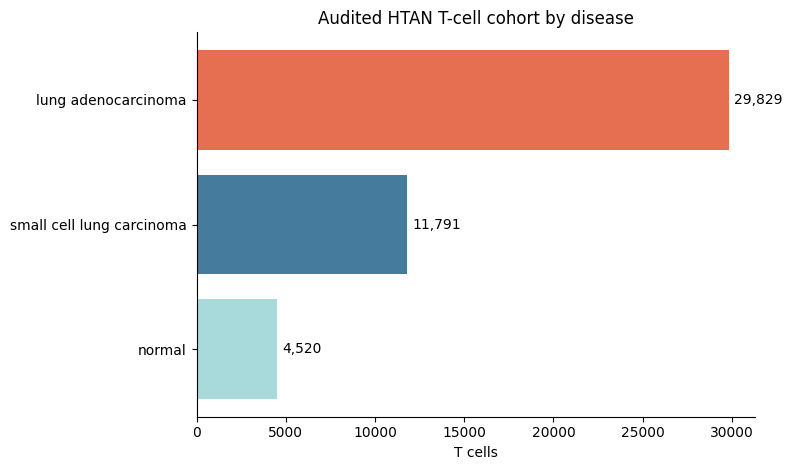

In [3]:
plot = htan.sort_values("cells")
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(plot["disease"], plot["cells"], color=["#A8DADC", "#457B9D", "#E76F51"])
ax.bar_label(bars, labels=[f"{v:,}" for v in plot["cells"]], padding=4)
ax.set_xlabel("T cells")
ax.set_title("Audited HTAN T-cell cohort by disease")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
pd.DataFrame([
    {
        "dataset": "HTAN T cells",
        "scale": f'{summary["htan_tcell_h5ad"]["cells"]:,} cells',
        "key check": "raw counts and donor labels present",
        "decision": "primary discovery",
    },
    {
        "dataset": "GSE263196",
        "scale": f'{summary["gse263196"]["total_in_tissue_spots"]:,} spots / 5 samples',
        "key check": "complete Visium bundles",
        "decision": "spatial validation",
    },
    {
        "dataset": "OMIX002441",
        "scale": f'{summary["omix002441"]["t_cells"]:,} T cells / 11 patients',
        "key check": "only 2 robust paired donors",
        "decision": "sensitivity analysis",
    },
    {
        "dataset": "GSE261348",
        "scale": f'{summary["gse261348"]["expression_aois"]} AOIs',
        "key check": "clinical outcomes absent",
        "decision": "blocked pending join",
    },
])

,dataset,scale,key check,decision
0,HTAN T cells,"46,140 cells",raw counts and donor labels present,primary discovery
1,GSE263196,"15,774 spots / 5 samples",complete Visium bundles,spatial validation
2,OMIX002441,"1,039 T cells / 11 patients",only 2 robust paired donors,sensitivity analysis
3,GSE261348,175 AOIs,clinical outcomes absent,blocked pending join


## Takeaways

1. The current LUAD/LUSC repository work is exploratory provenance, not SCLC
   validation.
2. The HTAN object is sufficiently large for donor-held-out SCLC-versus-LUAD
   modeling, although the four-donor normal group limits generalization.
3. Visium spots must be deconvolved or annotated and aggregated to the five
   patient-level replicates; they must not be passed to Geneformer as if they
   were T cells.
4. OMIX002441 is valuable for direction/rank concordance, not as the main
   training cohort.
5. Treatment-response claims are not testable from the downloaded GSE261348
   workbooks without an external clinical outcome join.